# Experiment Prototype Title

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.interpolate import CubicSpline

In [ ]:
class FastSitnikovSimulation:
    """Fast, SciPy-based Sitnikov simulator with periodic focal-distance interpolation."""

    def __init__(
        self,
        e,
        n_focal_samples=4096,
        rtol=1e-7,
        atol=1e-10,
        max_step=np.inf,
        solver_method="RK45",
        auto_solver_trials=4,
        phi_time_window=20.0 * np.pi,
        focal_interp="linear",
    ):
        if not (0.0 <= e < 1.0):
            raise ValueError("e must satisfy 0 <= e < 1")
        if n_focal_samples < 16:
            raise ValueError("n_focal_samples must be at least 16")
        if focal_interp not in ("linear", "cubic"):
            raise ValueError("focal_interp must be 'linear' or 'cubic'")

        self.e = float(e)
        self.period = 2.0 * np.pi
        self.a = 0.5
        self.rtol = float(rtol)
        self.atol = float(atol)
        self.max_step = float(max_step)
        self.phi_time_window = float(phi_time_window)
        self.focal_interp = focal_interp

        self.r_min = 0.5 * (1.0 - self.e)
        self.r_min_sq = self.r_min * self.r_min
        self.tau_min = np.pi * (self.r_min ** 1.5)

        self._n_focal_samples = int(n_focal_samples)
        self._t_grid = np.linspace(0.0, self.period, self._n_focal_samples, endpoint=False)
        self.focal_distance_array = self._build_focal_distance_array(self._t_grid)

        self._dt_grid = self.period / self._n_focal_samples
        self._inv_dt_grid = 1.0 / self._dt_grid
        self._r_periodic = np.concatenate((self.focal_distance_array, [self.focal_distance_array[0]]))
        self._t_periodic = np.linspace(0.0, self.period, self._n_focal_samples + 1)

        self._focal_spline = None
        if self.focal_interp == "cubic":
            self._focal_spline = CubicSpline(self._t_periodic, self._r_periodic, bc_type="periodic")

        self._escape_event = self._build_escape_event()

        if solver_method == "auto":
            self.solver_method = self._choose_fastest_solver(auto_solver_trials)
        else:
            self.solver_method = solver_method

    def _solve_kepler(self, M, tol=1e-14, max_iter=16):
        E = np.array(M, dtype=float, copy=True)
        for _ in range(max_iter):
            f = E - self.e * np.sin(E) - M
            fp = 1.0 - self.e * np.cos(E)
            dE = f / fp
            E -= dE
            if np.max(np.abs(dE)) < tol:
                break
        return E

    def _build_focal_distance_array(self, t_grid):
        M = np.mod(t_grid, self.period)
        E = self._solve_kepler(M)
        return self.a * (1.0 - self.e * np.cos(E))

    def _focal_distance_scalar(self, t):
        tau = t % self.period
        if self.focal_interp == "cubic":
            return float(self._focal_spline(tau))

        u = tau * self._inv_dt_grid
        i = int(u)
        frac = u - i
        r0 = self._r_periodic[i]
        r1 = self._r_periodic[i + 1]
        return r0 + frac * (r1 - r0)

    def focal_distance(self, t):
        tau = np.mod(t, self.period)
        if self.focal_interp == "cubic":
            return self._focal_spline(tau)
        return np.interp(tau, self._t_periodic, self._r_periodic)

    def _rhs(self, t, y):
        z, vz = y
        r = self._focal_distance_scalar(t)
        denom = (z * z + r * r) ** 1.5
        return (vz, -z / denom)

    def _escape_polynomial(self, z, vz):
        vz2 = vz * vz
        return 0.25 * vz2 * vz2 * (z * z + self.r_min_sq) - 1.0

    def _is_escaped(self, z, vz):
        return self._escape_polynomial(z, vz) >= 0.0

    def _build_escape_event(self):
        def event(t, y):
            return self._escape_polynomial(y[0], y[1])

        event.terminal = True
        event.direction = 1.0
        return event

    def _build_gated_crossing_event(self, t0):
        tau = self.tau_min
        t_left = t0 + 0.4 * tau
        t_right = t0 + 0.8 * tau
        inv_span = 1.0 / (t_right - t_left)

        def event(ti, yi):
            if ti < t_left:
                return 1.0
            if ti < t_right:
                x = (t_right - ti) * inv_span
                return x + (1.0 - x) * yi[0]
            return yi[0]

        event.terminal = True
        event.direction = -1.0
        return event

    def trajectory_fast(self, z0, vz0, t0, T, dt):
        if T <= 0.0:
            raise ValueError("T must be positive")
        if dt <= 0.0:
            raise ValueError("dt must be positive")

        t_start = float(t0)
        t_end = t_start + float(T)
        t_eval = np.arange(t_start, t_end, float(dt))
        if t_eval.size == 0 or t_eval[-1] < t_end:
            t_eval = np.append(t_eval, t_end)

        sol = solve_ivp(
            self._rhs,
            (t_start, t_end),
            (float(z0), float(vz0)),
            method=self.solver_method,
            t_eval=t_eval,
            rtol=self.rtol,
            atol=self.atol,
            max_step=self.max_step,
        )
        if not sol.success:
            raise RuntimeError(f"trajectory_fast integration failed: {sol.message}")

        return sol.y[0], sol.y[1]

    def stroboscopic(self, z, v):
        z0 = float(z)
        v0 = float(v)

        sol = solve_ivp(
            self._rhs,
            (0.0, self.period),
            (z0, v0),
            method=self.solver_method,
            rtol=self.rtol,
            atol=self.atol,
            max_step=self.max_step,
        )
        if not sol.success:
            raise RuntimeError(f"stroboscopic integration failed: {sol.message}")

        return float(sol.y[0, -1]), float(sol.y[1, -1])

    def _phi_fast_impl(self, v, t, method, t_max):
        t0 = float(t)
        v0 = float(v)

        if v0 < 0.0:
            raise ValueError(f"Velocity must be non-negative, got v = {v}")
        if v0 == 0.0:
            return 0.0, float(np.mod(t0, self.period))

        if self._is_escaped(0.0, v0):
            return None, None

        crossing_event = self._build_gated_crossing_event(t0)
        sol = solve_ivp(
            self._rhs,
            (t0, t0 + float(t_max)),
            (0.0, v0),
            method=method,
            events=(crossing_event, self._escape_event),
            rtol=self.rtol,
            atol=self.atol,
            max_step=self.max_step,
        )
        if not sol.success:
            raise RuntimeError(f"phi_fast integration failed: {sol.message}")

        t_cross = np.inf
        t_escape = np.inf

        if len(sol.t_events[0]) > 0:
            t_cross = float(sol.t_events[0][0])
            v_cross = float(sol.y_events[0][0][1])
        if len(sol.t_events[1]) > 0:
            t_escape = float(sol.t_events[1][0])

        if not np.isfinite(t_cross) or t_escape <= t_cross:
            return None, None

        if v_cross > 1e-8:
            raise RuntimeError("Detected crossing is not downward as expected")

        return max(0.0, -v_cross), float(np.mod(t_cross, self.period))

    def _choose_fastest_solver(self, trials):
        '''
        Not used by default because RK45 is generally faster for this problem.
        Run timing trials to choose the fastest ODE solver for phi_fast.
        '''
        candidates = ("DOP853", "RK45")
        trial_count = max(1, int(trials))
        v_samples = np.linspace(0.2, 1.0, trial_count)
        t_samples = np.linspace(0.0, self.period, trial_count, endpoint=False)
        timings = {}

        for method in candidates:
            start = time.perf_counter()
            for v0, t0 in zip(v_samples, t_samples):
                self._phi_fast_impl(v0, t0, method=method, t_max=2.0 * self.period)
            timings[method] = time.perf_counter() - start

        return min(timings, key=timings.get)

    def phi_fast(self, v, t, t_max=None):
        if t_max is None:
            t_max = self.phi_time_window
        return self._phi_fast_impl(v=v, t=t, method=self.solver_method, t_max=t_max)

    def crossings_fast(self, v, t, max_crossings=1000, t_max=None):
        if max_crossings <= 0:
            return 0

        v_curr = float(v)
        if v_curr < 0.0:
            raise ValueError(f"Velocity must be non-negative, got v = {v}")

        t_curr = float(np.mod(t, self.period))
        count = 0

        for _ in range(int(max_crossings)):
            v_next, t_next = self.phi_fast(v_curr, t_curr, t_max=t_max)
            if v_next is None:
                break
            count += 1
            v_curr, t_curr = v_next, t_next

        return count

In [3]:
# Quick sanity checks
sim = FastSitnikovSimulation(e=0.5, solver_method="auto", auto_solver_trials=3)

print("Selected solver:", sim.solver_method)
print("r_min:", sim.r_min)
print("tau_min:", sim.tau_min)

# Periodicity and evenness checks for focal distance
rng = np.random.default_rng(42)
t_samples = rng.uniform(-20.0 * np.pi, 20.0 * np.pi, size=200)
periodicity_err = np.max(np.abs(sim.focal_distance(t_samples + 2.0 * np.pi) - sim.focal_distance(t_samples)))
evenness_err = np.max(np.abs(sim.focal_distance(-t_samples) - sim.focal_distance(t_samples)))
print("max periodicity error:", periodicity_err)
print("max evenness error:", evenness_err)

# One-step map check
v1, t1 = sim.phi_fast(v=0.7, t=0.1)
print("phi_fast(0.7, 0.1) ->", (v1, t1))

# Short trajectory check
z, vz = sim.trajectory_fast(z0=0.0, vz0=0.7, t0=0.1, T=8.0, dt=0.02)
print("trajectory lengths:", len(z), len(vz))
print("trajectory sample z[:3]:", z[:3])

# Crossing count sample
n_cross = sim.crossings_fast(v=0.7, t=0.1, max_crossings=20)
print("crossings before escape (cap=20):", n_cross)

# Regression checks for velocity-domain behavior
v_zero, t_zero = sim.phi_fast(v=0.0, t=1.234)
print("phi_fast(0.0, 1.234) ->", (v_zero, t_zero))
assert v_zero == 0.0
assert abs(t_zero - float(np.mod(1.234, 2.0 * np.pi))) < 1e-14

try:
    sim.phi_fast(v=-1e-6, t=0.1)
    raise AssertionError("Expected ValueError for negative velocity")
except ValueError:
    print("negative-v check: OK (ValueError raised)")

# Stroboscopic map check at t=2pi from (z, v, t=0)
z_strobo, v_strobo = sim.stroboscopic(z=0.05, v=0.7)
print("stroboscopic(0.05, 0.7) ->", (z_strobo, v_strobo))

Selected solver: RK45
r_min: 0.25
tau_min: 0.39269908169872414
max periodicity error: 1.887379141862766e-15
max evenness error: 2.220446049250313e-16
phi_fast(0.7, 0.1) -> (0.5030858833061809, 0.665274591573899)
trajectory lengths: 401 401
trajectory sample z[:3]: [0.         0.01394447 0.02756474]
crossings before escape (cap=20): 20
phi_fast(0.0, 1.234) -> (0.0, 1.234)
negative-v check: OK (ValueError raised)
stroboscopic(0.05, 0.7) -> (-0.09037155615753756, 0.3886669918529718)


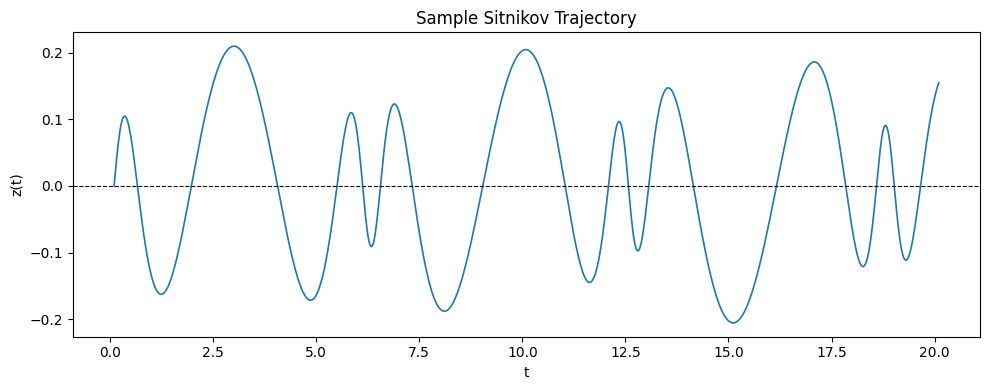

Regular regime (t_max=20.0pi): 100 phi calls took 0.960851 s
Average per call: 0.009609 s
Valid crossings found: 100/100
High-v regime (t_max=20.0pi): 10 phi calls took 0.097630 s
Average per call: 0.009763 s
Valid crossings found: 6/10


In [8]:
# Sample trajectory plot + phi benchmarks
sim_bench = FastSitnikovSimulation(e=0.5)
t_max_bench = 20.0 * np.pi

# 1) Sample trajectory and plot
z_plot, vz_plot = sim_bench.trajectory_fast(z0=0.0, vz0=0.7, t0=0.1, T=20.0, dt=0.02)
t_plot = 0.1 + np.arange(z_plot.size) * 0.02

plt.figure(figsize=(10, 4))
plt.plot(t_plot, z_plot, lw=1.2)
plt.axhline(0.0, color="k", ls="--", lw=0.8)
plt.xlabel("t")
plt.ylabel("z(t)")
plt.title("Sample Sitnikov Trajectory")
plt.tight_layout()
plt.show()

rng = np.random.default_rng(123)

# 2) Benchmark: 100 phi calls for regular non-escape points with v <= 1.0
v_regular = rng.uniform(0.1, 1.0, size=100)
t_regular = rng.uniform(0.0, 2.0 * np.pi, size=100)

start_regular = time.perf_counter()
regular_results = [
    sim_bench.phi_fast(v=float(v), t=float(t), t_max=t_max_bench)
    for v, t in zip(v_regular, t_regular)
]
elapsed_regular = time.perf_counter() - start_regular
valid_regular = sum(1 for v_next, _ in regular_results if v_next is not None)

print(f"Regular regime (t_max={t_max_bench/np.pi:.1f}pi): 100 phi calls took {elapsed_regular:.6f} s")
print(f"Average per call: {elapsed_regular / 100.0:.6f} s")
print(f"Valid crossings found: {valid_regular}/100")

# 3) Benchmark: 10 phi calls for higher-v points with 1.5 <= v <= 1.9
v_high = rng.uniform(1.5, 1.9, size=10)
t_high = rng.uniform(0.0, 2.0 * np.pi, size=10)

start_high = time.perf_counter()
high_results = [
    sim_bench.phi_fast(v=float(v), t=float(t), t_max=t_max_bench)
    for v, t in zip(v_high, t_high)
]
elapsed_high = time.perf_counter() - start_high
valid_high = sum(1 for v_next, _ in high_results if v_next is not None)

print(f"High-v regime (t_max={t_max_bench/np.pi:.1f}pi): 10 phi calls took {elapsed_high:.6f} s")
print(f"Average per call: {elapsed_high / 10.0:.6f} s")
print(f"Valid crossings found: {valid_high}/10")

In [10]:
# Benchmark phi_fast error/time against reference phi from src
from pathlib import Path
import sys

# Make src package importable from this notebook location
cwd = Path.cwd().resolve()
src_root = None
for p in [cwd, *cwd.parents]:
    if (p / "src" / "integrator" / "integrate.py").exists():
        src_root = p
        break
if src_root is None:
    raise RuntimeError("Could not locate src/integrator/integrate.py from current working tree")
if str(src_root) not in sys.path:
    sys.path.insert(0, str(src_root))

from src.integrator.integrate import phi as phi_reference

def wrapped_time_error(t_fast, t_ref):
    # Compare angles/times modulo 2pi using shortest wrapped distance
    return abs(((t_fast - t_ref + np.pi) % (2.0 * np.pi)) - np.pi)

e_cmp = 0.5
sim_cmp = FastSitnikovSimulation(e=e_cmp)
rng_cmp = np.random.default_rng(2026)
t_max_cmp = 20.0 * np.pi

# Regular regime comparison (mostly returning points)
N_reg = 100
v_reg = rng_cmp.uniform(0.1, 1.0, size=N_reg)
t_reg = rng_cmp.uniform(0.0, 2.0 * np.pi, size=N_reg)

start_fast_reg = time.perf_counter()
fast_reg = [sim_cmp.phi_fast(float(v), float(t), t_max=t_max_cmp) for v, t in zip(v_reg, t_reg)]
time_fast_reg = time.perf_counter() - start_fast_reg

start_ref_reg = time.perf_counter()
ref_reg = [phi_reference(e_cmp, float(v), float(t), t_max=t_max_cmp) for v, t in zip(v_reg, t_reg)]
time_ref_reg = time.perf_counter() - start_ref_reg

v_err_reg = []
t_err_reg = []
both_ok_reg = 0
mismatch_reg = 0
for (vf, tf), (vr, tr) in zip(fast_reg, ref_reg):
    if (vf is None) != (vr is None):
        mismatch_reg += 1
        continue
    if vf is None:
        continue
    both_ok_reg += 1
    v_err_reg.append(abs(vf - vr))
    t_err_reg.append(wrapped_time_error(tf, tr))

print(f"=== Regular regime: v in [0.1, 1.0], N={N_reg}, t_max={t_max_cmp/np.pi:.1f}pi ===")
print(f"phi_fast time: {time_fast_reg:.6f} s")
print(f"phi_ref  time: {time_ref_reg:.6f} s")
print(f"speedup (ref/fast): {time_ref_reg / time_fast_reg:.2f}x")
print(f"both-return count: {both_ok_reg}/{N_reg}")
print(f"return mismatch count: {mismatch_reg}/{N_reg}")
if both_ok_reg > 0:
    print(f"max |dv|: {np.max(v_err_reg):.3e}")
    print(f"mean |dv|: {np.mean(v_err_reg):.3e}")
    print(f"max |dt_mod|: {np.max(t_err_reg):.3e}")
    print(f"mean |dt_mod|: {np.mean(t_err_reg):.3e}")

# Higher-v regime comparison
N_hi = 10
v_hi = rng_cmp.uniform(1.5, 1.9, size=N_hi)
t_hi = rng_cmp.uniform(0.0, 2.0 * np.pi, size=N_hi)

start_fast_hi = time.perf_counter()
fast_hi = [sim_cmp.phi_fast(float(v), float(t), t_max=t_max_cmp) for v, t in zip(v_hi, t_hi)]
time_fast_hi = time.perf_counter() - start_fast_hi

start_ref_hi = time.perf_counter()
ref_hi = [phi_reference(e_cmp, float(v), float(t), t_max=t_max_cmp) for v, t in zip(v_hi, t_hi)]
time_ref_hi = time.perf_counter() - start_ref_hi

v_err_hi = []
t_err_hi = []
both_ok_hi = 0
mismatch_hi = 0
for (vf, tf), (vr, tr) in zip(fast_hi, ref_hi):
    if (vf is None) != (vr is None):
        mismatch_hi += 1
        continue
    if vf is None:
        continue
    both_ok_hi += 1
    v_err_hi.append(abs(vf - vr))
    t_err_hi.append(wrapped_time_error(tf, tr))

print(f"\n=== High-v regime: v in [1.5, 1.9], N={N_hi}, t_max={t_max_cmp/np.pi:.1f}pi ===")
print(f"phi_fast time: {time_fast_hi:.6f} s")
print(f"phi_ref  time: {time_ref_hi:.6f} s")
print(f"speedup (ref/fast): {time_ref_hi / time_fast_hi:.2f}x")
print(f"both-return count: {both_ok_hi}/{N_hi}")
print(f"return mismatch count: {mismatch_hi}/{N_hi}")
if both_ok_hi > 0:
    print(f"max |dv|: {np.max(v_err_hi):.3e}")
    print(f"mean |dv|: {np.mean(v_err_hi):.3e}")
    print(f"max |dt_mod|: {np.max(t_err_hi):.3e}")
    print(f"mean |dt_mod|: {np.mean(t_err_hi):.3e}")

=== Regular regime: v in [0.1, 1.0], N=100, t_max=20.0pi ===
phi_fast time: 0.791359 s
phi_ref  time: 9.408167 s
speedup (ref/fast): 11.89x
both-return count: 100/100
return mismatch count: 0/100
max |dv|: 6.737e-07
mean |dv|: 9.092e-08
max |dt_mod|: 5.519e-07
mean |dt_mod|: 1.245e-07

=== High-v regime: v in [1.5, 1.9], N=10, t_max=20.0pi ===
phi_fast time: 0.102528 s
phi_ref  time: 4.532992 s
speedup (ref/fast): 44.21x
both-return count: 4/10
return mismatch count: 0/10
max |dv|: 9.966e-07
mean |dv|: 5.360e-07
max |dt_mod|: 7.762e-06
mean |dt_mod|: 3.462e-06
